# Analysis weather data for Madrid
- Analysis the relationship between temperature and other attributes

In [262]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# Load data

In [263]:
weather_data = pd.read_csv('weather_madrid_LEMD_1997_2015.csv')

weather_data.head(5)

,CET,Max TemperatureC,Mean TemperatureC,Min TemperatureC,Dew PointC,MeanDew PointC,Min DewpointC,Max Humidity,Mean Humidity,Min Humidity,...,Max VisibilityKm,Mean VisibilityKm,Min VisibilitykM,Max Wind SpeedKm/h,Mean Wind SpeedKm/h,Max Gust SpeedKm/h,Precipitationmm,CloudCover,Events,WindDirDegrees
0,1997-1-1,7.0,4.0,2.0,5.0,3.0,2.0,100.0,95.0,76.0,...,10.0,9.0,4.0,13,6,NaN,0.0,6.0,NaN,229
1,1997-1-2,7.0,3.0,0.0,6.0,3.0,0.0,100.0,92.0,71.0,...,10.0,9.0,4.0,26,8,47.0,0.0,5.0,Rain,143
2,1997-1-3,5.0,3.0,2.0,5.0,1.0,-1.0,100.0,85.0,70.0,...,10.0,10.0,7.0,27,19,NaN,0.0,6.0,Rain-Snow,256
3,1997-1-4,7.0,3.0,-1.0,-2.0,-3.0,-4.0,86.0,63.0,49.0,...,10.0,10.0,10.0,27,19,40.0,0.0,2.0,NaN,284
4,1997-1-5,2.0,0.0,-1.0,2.0,0.0,-3.0,100.0,95.0,86.0,...,10.0,5.0,1.0,14,6,NaN,0.0,7.0,Snow,2


# Data preparation

fill NA

In [264]:
weather_data['CET'] = pd.to_datetime(weather_data['CET'], format='%Y-%m-%d')

In [265]:
# 获取每一列的数据类型
column_types = weather_data.dtypes.to_dict()

# 打印每一列的名称和对应的数据类型
for column, data_type in column_types.items():
    print(f"Column '{column}': {data_type}")

Column 'CET': datetime64[ns]
Column 'Max TemperatureC': float64
Column 'Mean TemperatureC': float64
Column 'Min TemperatureC': float64
Column 'Dew PointC': float64
Column 'MeanDew PointC': float64
Column 'Min DewpointC': float64
Column 'Max Humidity': float64
Column ' Mean Humidity': float64
Column ' Min Humidity': float64
Column ' Max Sea Level PressurehPa': int64
Column ' Mean Sea Level PressurehPa': int64
Column ' Min Sea Level PressurehPa': int64
Column ' Max VisibilityKm': float64
Column ' Mean VisibilityKm': float64
Column ' Min VisibilitykM': float64
Column ' Max Wind SpeedKm/h': int64
Column ' Mean Wind SpeedKm/h': int64
Column ' Max Gust SpeedKm/h': float64
Column 'Precipitationmm': float64
Column ' CloudCover': float64
Column ' Events': object
Column 'WindDirDegrees': int64


In [266]:
def count_empty_value():
    # 计算每一列的缺失值数量
    col_null = weather_data.isnull().sum(axis=0)

    # 统计整个数据集的缺失值数量
    total_null = weather_data.isnull().sum().sum()

    # 打印结果
    print("\nMissing value in each column：\n", col_null.sort_values(ascending=False))


In [267]:
count_empty_value()


Missing value in each column：
  Events                        5014
 Max Gust SpeedKm/h            3306
 CloudCover                    1372
 Min VisibilitykM               940
 Max VisibilityKm               940
 Mean VisibilityKm              940
Mean TemperatureC                 3
 Mean Humidity                    2
Min TemperatureC                  2
Dew PointC                        2
MeanDew PointC                    2
Min DewpointC                     2
Max Humidity                      2
 Min Humidity                     2
Max TemperatureC                  2
CET                               0
Precipitationmm                   0
 Mean Sea Level PressurehPa       0
 Mean Wind SpeedKm/h              0
 Max Wind SpeedKm/h               0
 Min Sea Level PressurehPa        0
 Max Sea Level PressurehPa        0
WindDirDegrees                    0
dtype: int64


In [268]:
# fill events empty values
weather_data[' Events'].fillna('Sunny', inplace=True)

# fill max gust empty values
weather_data[' Max Gust SpeedKm/h'].fillna(0, inplace=True)

In [269]:
print(weather_data[' Max VisibilityKm'].mean())
print(weather_data[' Max VisibilityKm'].max())
print(weather_data[' Min VisibilitykM'].mean())
print(weather_data[' CloudCover'].mean())

14.64407356948229
31.0
9.134877384196185
3.2060661764705882


In [270]:
# fill max visb empty values
weather_data[' Max VisibilityKm'].fillna(14, inplace=True)
# fill min visb empty values
weather_data[' Min VisibilitykM'].fillna(9, inplace=True)
# fill cloudcover empty values
weather_data[' CloudCover'].fillna(3, inplace=True)
# fill mean visb empty values
weather_data[' Mean VisibilityKm'].fillna(11, inplace=True)

In [271]:
weather_data.dropna(inplace=True)


Replace wind dir

In [272]:
# 将小于等于 0 的值替换为 0
weather_data['WindDirDegrees'] = weather_data['WindDirDegrees'].apply(lambda x: max(x, 0))

# 将大于等于 360 的值替换为 360
weather_data['WindDirDegrees'] = weather_data['WindDirDegrees'].apply(lambda x: min(x, 360))

Dummy data

In [273]:
# 获取不同的值
unique_events = weather_data[' Events'].unique()

# 打印不同的值
print("Unique value:", unique_events)
print("There're", len(unique_events), "types class.")

Unique value: ['Sunny' 'Rain' 'Rain-Snow' 'Snow' 'Fog' 'Fog-Rain' 'Rain-Thunderstorm'
 'Thunderstorm' 'Rain-Hail-Thunderstorm' 'Fog-Thunderstorm' 'Tornado'
 'Fog-Rain-Thunderstorm' 'Fog-Rain-Snow' 'Fog-Snow'
 'Rain-Snow-Thunderstorm' 'Rain-Hail']
There're 16 types class.


In [274]:
# 使用 factorize() 函数将 'Events' 列转换为数字
weather_data['Event_Code'] = weather_data[' Events'].factorize()[0]

# 打印结果
print(weather_data[[' Events', 'Event_Code']].drop_duplicates())

                      Events  Event_Code
0                      Sunny           0
1                       Rain           1
2                  Rain-Snow           2
4                       Snow           3
10                       Fog           4
32                  Fog-Rain           5
106        Rain-Thunderstorm           6
209             Thunderstorm           7
464   Rain-Hail-Thunderstorm           8
500         Fog-Thunderstorm           9
1612                 Tornado          10
1764   Fog-Rain-Thunderstorm          11
4237           Fog-Rain-Snow          12
4264                Fog-Snow          13
5048  Rain-Snow-Thunderstorm          14
6523               Rain-Hail          15


# Feature Eng

In [275]:
weather_data = weather_data.drop(columns=[' Events'])

In [276]:
season_dict = {
    1: 1, 2: 1, 3: 2,  # Winter
    4: 2, 5: 2, 6: 3,  # Spring
    7: 3, 8: 3, 9: 3,  # Summer
    10: 4, 11: 4, 12: 1  # Fall
}

# 提取月份并映射到季节
weather_data['Month'] = pd.to_datetime(weather_data['CET']).dt.month
weather_data['Season'] = weather_data['Month'].map(season_dict)
weather_data.drop(columns=['Month'], inplace=True)

In [277]:
def mean_group_season(columns):
    for c in columns:
        seasonal_mean = weather_data.groupby("Season")[c].mean()
        season_dict_2 = {
            1: 'Winter', 2: 'Spring', 3:'Summber', 4:'Fall'
        }
        seasonal_mean.index = seasonal_mean.index.map(season_dict_2)
        print("Mean value of " + c + " group by season")
        display(seasonal_mean)

In [278]:
mean_group_season(['Mean TemperatureC', 'MeanDew PointC', ' Mean Humidity', ' Mean Sea Level PressurehPa', ' Mean VisibilityKm', ' Mean Wind SpeedKm/h', 
                   'Precipitationmm'])

Mean value of Mean TemperatureC group by season


Season
Winter      6.145498
Spring     13.286223
Summber    23.138488
Fall       12.223469
Name: Mean TemperatureC, dtype: float64

Mean value of MeanDew PointC group by season


Season
Winter     1.376863
Spring     4.445962
Summber    7.501529
Fall       5.972390
Name: MeanDew PointC, dtype: float64

Mean value of  Mean Humidity group by season


...

Season
Winter     10.214073
Spring     11.718527
Summber    12.749235
Fall       11.285591
Name:  Mean VisibilityKm, dtype: float64

Mean value of  Mean Wind SpeedKm/h group by season


Season
Winter     8.559928
Spring     9.970309
Summber    9.417650
Fall       8.390854
Name:  Mean Wind SpeedKm/h, dtype: float64

Mean value of Precipitationmm group by season


Season
Winter     0.102821
Spring     0.129709
Summber    0.074801
Fall       0.168499
Name: Precipitationmm, dtype: float64

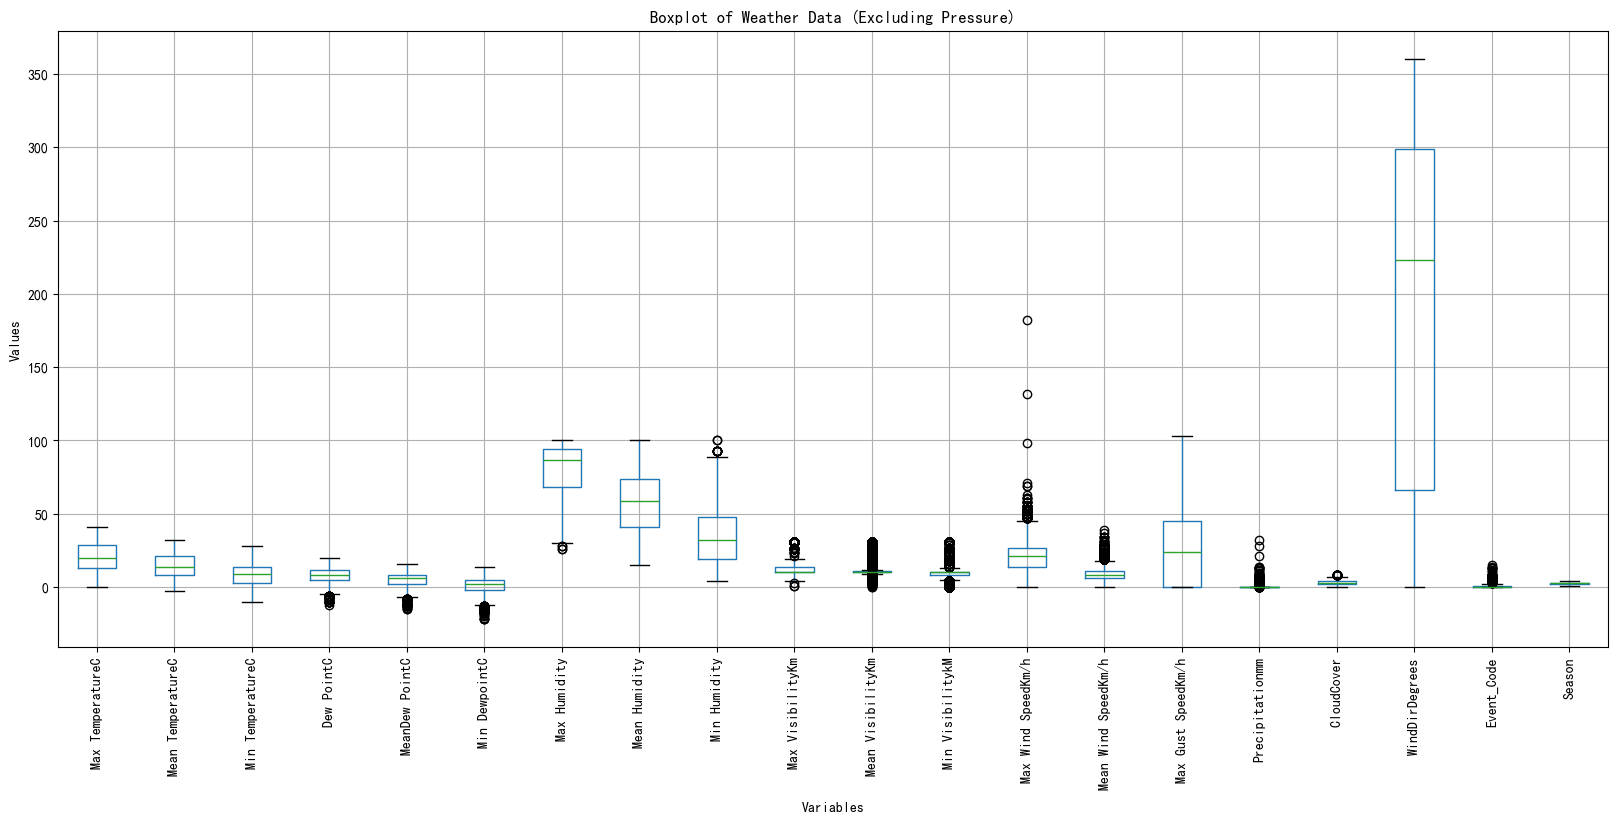

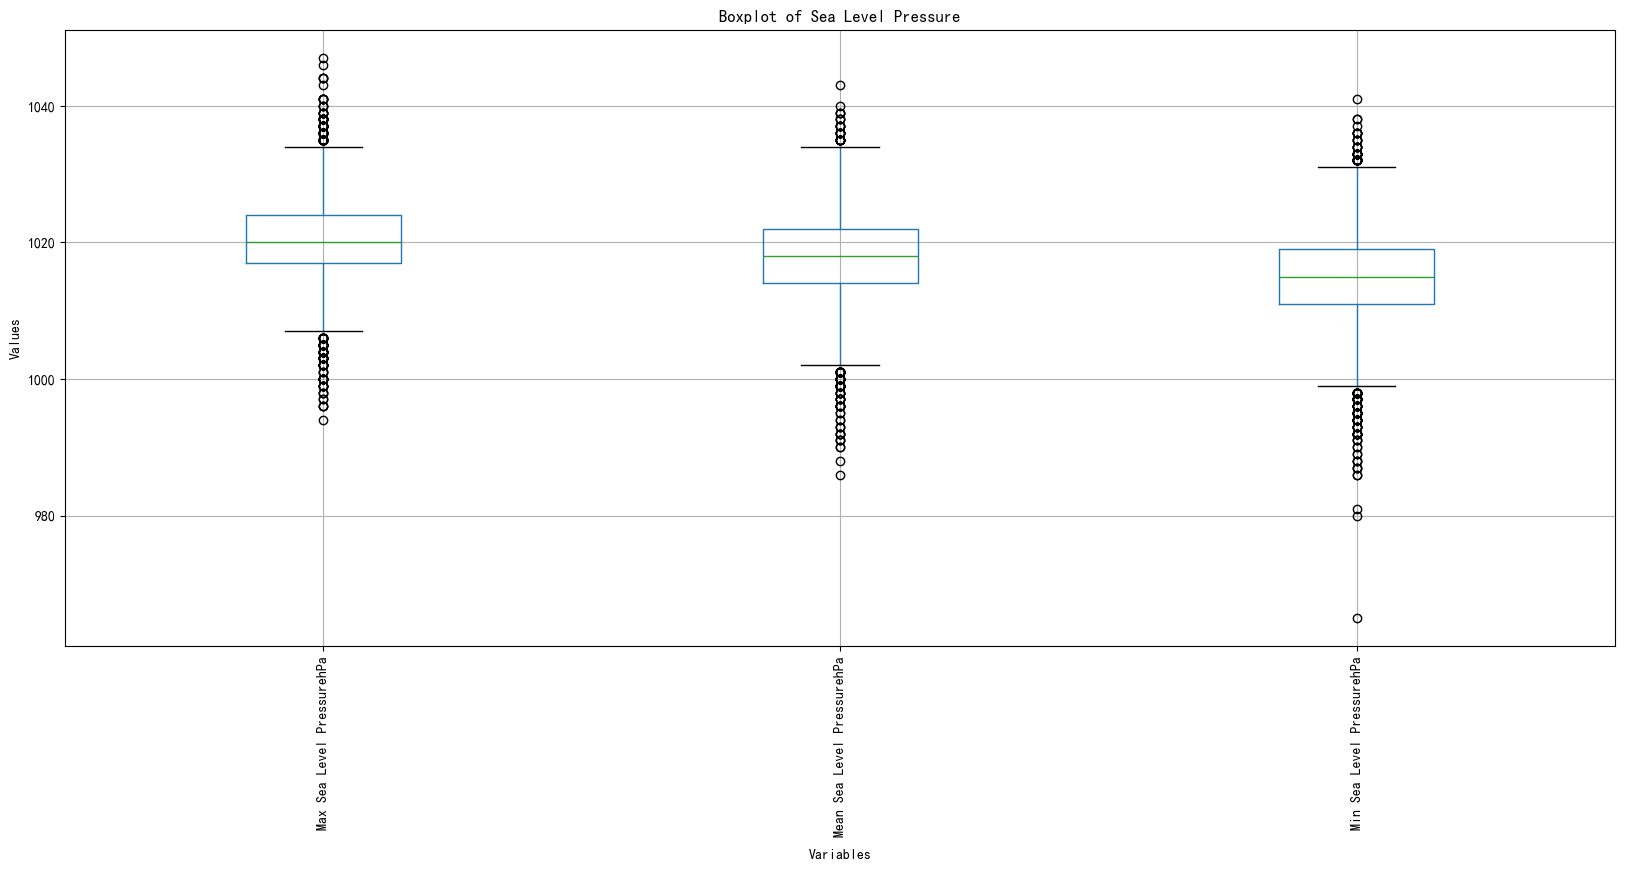

In [279]:
weather_box = weather_data
# 创建一个新的图形
plt.figure(figsize=(20, 8))

# 绘制第一张箱线图（不包含 ' Max Sea Level PressurehPa', ' Mean Sea Level PressurehPa', ' Min Sea Level PressurehPa' 这三列）
weather_box.drop(columns=[' Max Sea Level PressurehPa', ' Mean Sea Level PressurehPa', ' Min Sea Level PressurehPa']).boxplot()

# 添加其他绘图设置（如果需要）
plt.title('Boxplot of Weather Data (Excluding Pressure)')
plt.xlabel('Variables')
plt.ylabel('Values')

# 旋转 X 轴标签
plt.xticks(rotation=90)

# 显示图形
plt.show()

# 创建第二个 DataFrame，只包含这三列
weather_box_2 = weather_data[[' Max Sea Level PressurehPa', ' Mean Sea Level PressurehPa', ' Min Sea Level PressurehPa']]

# 创建第二张箱线图
plt.figure(figsize=(20, 8))
weather_box_2.boxplot()

# 添加其他绘图设置（如果需要）
plt.title('Boxplot of Sea Level Pressure')
plt.xlabel('Variables')
plt.ylabel('Values')

# 旋转 X 轴标签
plt.xticks(rotation=90)

# 显示图形
plt.show()


In [280]:
def scatter_point_columns(columns):
    for c in columns:
        plt.scatter(weather_data['Mean TemperatureC'], weather_data[c])
        plt.xlabel('Mean Temperature (°C)')
        plt.ylabel('Mean Dew Point (°C)')
        plt.title('Scatter Plot: Mean Temperature vs.' + c)
        plt.grid(True)
        plt.show()

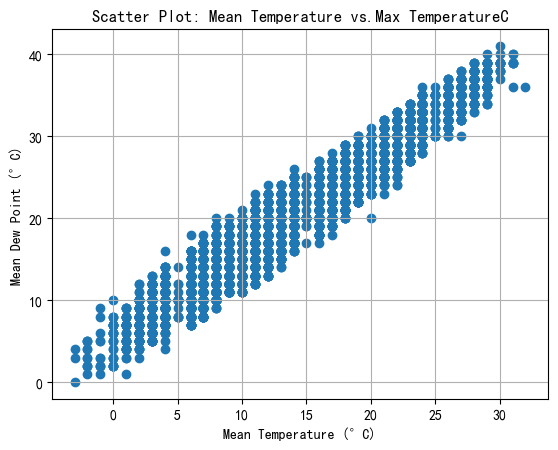

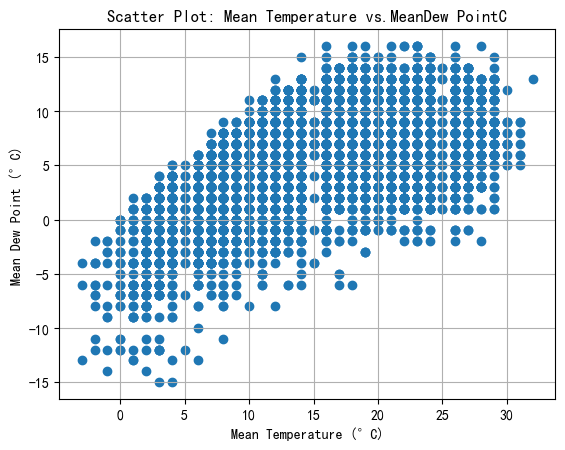

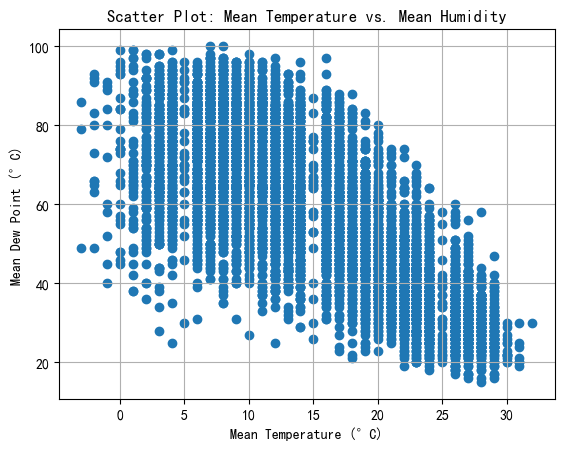

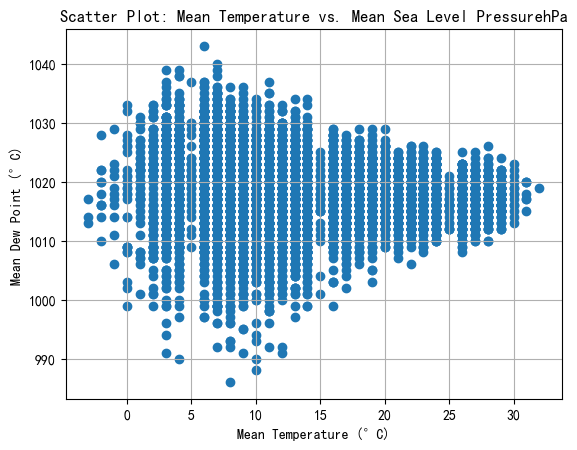

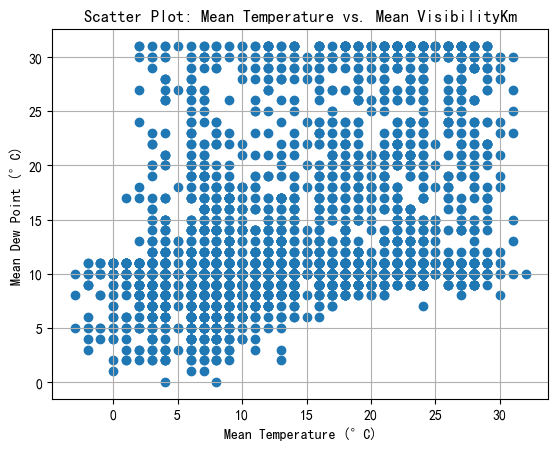

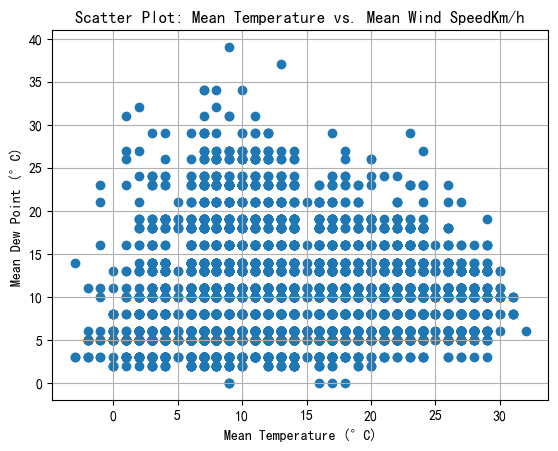

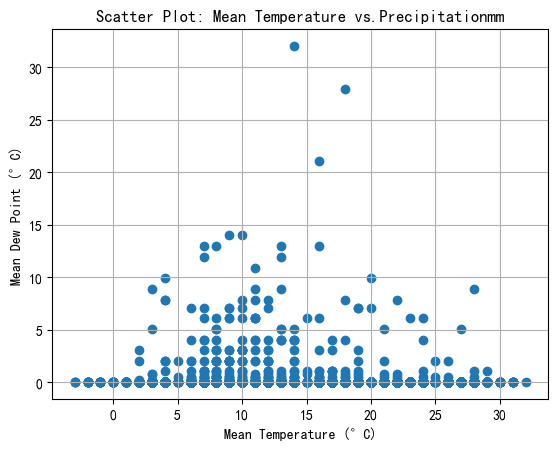

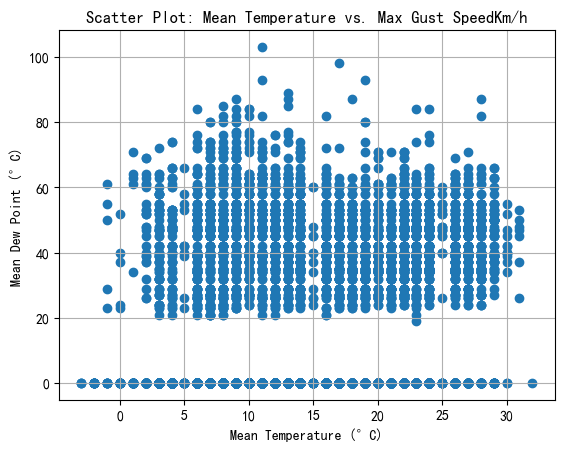

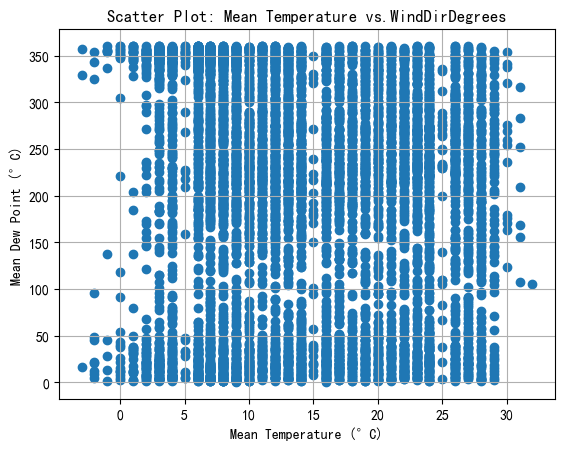

In [281]:
scatter_point_columns(['Max TemperatureC', 'MeanDew PointC', ' Mean Humidity', ' Mean Sea Level PressurehPa', ' Mean VisibilityKm', ' Mean Wind SpeedKm/h', 
                       'Precipitationmm', ' Max Gust SpeedKm/h', 'WindDirDegrees'])

In [282]:
# 计算每个类别的数量
category_counts = {}
total_events = len(weather_data['Event_Code'])
for code in weather_data['Event_Code']:
    if code in category_counts:
        category_counts[code] += 1
    else:
        category_counts[code] = 1

# 创建一个字典并指定元素
my_dict = {'Sunny': 0, 'Rain': 1, 'Rain-Snow': 2, 'Snow': 3, 'Fog': 4, 'Fog-Rain': 5, 'Rain-Thunderstorm': 6, 
           'Thunderstorm': 7, 'Rain-Hail-Thunderstorm': 8, 'Fog-Thunderstorm': 9, 'Tornado': 10, 
           'Fog-Rain-Thunderstorm': 11, 'Fog-Rain-Snow': 12, 'Fog-Snow': 13, 'Rain-Snow-Thunderstorm': 14, 'Rain-Hail': 15}
reversed_dict = {v: k for k, v in my_dict.items()}


# 计算每个类别的比例
category_proportions = {category: count / total_events * 100 for category, count in category_counts.items()}

# 按照比例从大到小排序
sorted_proportions = sorted(category_proportions.items(), key=lambda x: x[1], reverse=True)


# 打印类别和对应的比例
for category, proportion in sorted_proportions:
    category_text = reversed_dict.get(category, category)  # 获取对应的文本，如果不在字典中则保持原样
    print(f"{category_text}: {proportion:.1f}%")


Sunny: 73.6%
Rain: 16.7%
Rain-Thunderstorm: 3.6%
Fog: 3.4%
Fog-Rain: 1.0%
Thunderstorm: 0.7%
Rain-Snow: 0.5%
Snow: 0.2%
Rain-Hail-Thunderstorm: 0.1%
Fog-Snow: 0.1%
Fog-Thunderstorm: 0.0%
Tornado: 0.0%
Fog-Rain-Thunderstorm: 0.0%
Fog-Rain-Snow: 0.0%
Rain-Snow-Thunderstorm: 0.0%
Rain-Hail: 0.0%


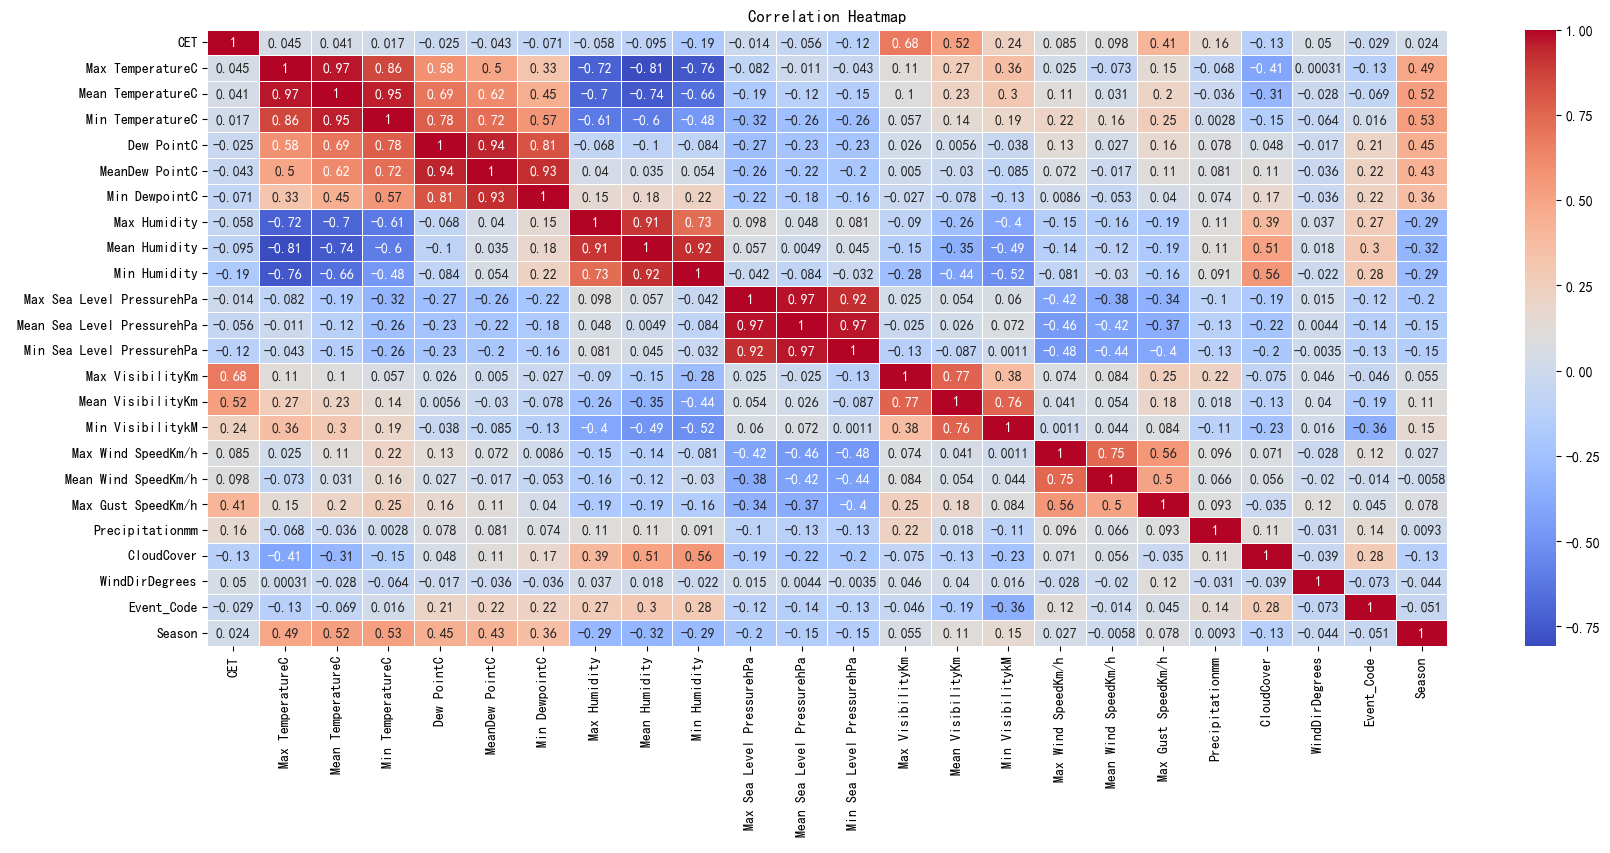

In [283]:
correlation_matrix = weather_data.corr()

# 绘制热力图
plt.figure(figsize=(20, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [284]:
weather = weather_data[['Dew PointC', 'MeanDew PointC','Min DewpointC', 'Max Humidity', ' Mean Humidity', ' Min Humidity', 
' CloudCover', 'Mean TemperatureC', 'Season']]


# Model & Analysis

In [285]:
# Assuming 'WSP125' is the target variable and other columns are features
X = weather.drop(columns=['Mean TemperatureC'])
y = weather['Mean TemperatureC']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(),
    'Ridge Regression': Ridge(),
    'Random Forest Regression': RandomForestRegressor(),
}

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    predictions = model.predict(X_test)

    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, predictions)
    print(f"\nModel: {name}")
    print(f"Mean Squared Error: {mse}")

    # Calculate R-squared
    r2 = r2_score(y_test, predictions)
    print(f"R-squared: {r2}")



Model: Linear Regression
Mean Squared Error: 1.7624509559888777
R-squared: 0.9696575134803868

Model: Lasso Regression
Mean Squared Error: 1.8247852057985943
R-squared: 0.9685843624073684

Model: Ridge Regression
Mean Squared Error: 1.7624466173839055
R-squared: 0.9696575881741321

Model: Random Forest Regression
Mean Squared Error: 0.8127949951052373
R-squared: 0.986006861014551


In [286]:
for name, model in models.items():
    # Compute cross-validation scores
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    
    # Convert negative MSE to positive
    cv_scores_positive = -cv_scores
    
    # Calculate mean and standard deviation of CV scores
    mean_cv_score = cv_scores_positive.mean()
    std_cv_score = cv_scores_positive.std()

    print(f"\nModel: {name}")
    print(f"Mean Cross-Validation MSE: {mean_cv_score:.2f}")
    print(f"Standard Deviation of Cross-Validation MSE: {std_cv_score:.2f}")



Model: Linear Regression
Mean Cross-Validation MSE: 1.80
Standard Deviation of Cross-Validation MSE: 0.28

Model: Lasso Regression
Mean Cross-Validation MSE: 1.84
Standard Deviation of Cross-Validation MSE: 0.27

Model: Ridge Regression
Mean Cross-Validation MSE: 1.80
Standard Deviation of Cross-Validation MSE: 0.28

Model: Random Forest Regression
Mean Cross-Validation MSE: 1.07
Standard Deviation of Cross-Validation MSE: 0.51


# Fine tune

In [287]:
# 假设您的数据框名为 weather
column_names = weather.columns
print(column_names)


Index(['Dew PointC', 'MeanDew PointC', 'Min DewpointC', 'Max Humidity',
       ' Mean Humidity', ' Min Humidity', ' CloudCover', 'Mean TemperatureC',
       'Season'],
      dtype='object')


In [288]:
# plan to only use mean value
weather.drop(columns=['Dew PointC', 'Min DewpointC', 'Max Humidity',
       ' Min Humidity'], inplace=True)

C:\Users\fhuur\AppData\Local\Temp\ipykernel_25860\26470590.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather.drop(columns=['Dew PointC', 'Min DewpointC', 'Max Humidity',


<Axes: >

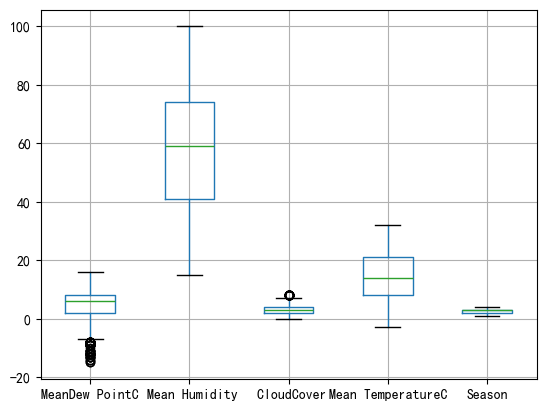

In [289]:
weather.boxplot()

In [290]:
# Assuming 'WSP125' is the target variable and other columns are features
X = weather.drop(columns=['Mean TemperatureC'])
y = weather['Mean TemperatureC']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(),
    'Ridge Regression': Ridge(),
    'Random Forest Regression': RandomForestRegressor(),
}

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    predictions = model.predict(X_test)

    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, predictions)
    print(f"\nModel: {name}")
    print(f"Mean Squared Error: {mse}")

    # Calculate R-squared
    r2 = r2_score(y_test, predictions)
    print(f"R-squared: {r2}")



Model: Linear Regression
Mean Squared Error: 2.19104778858807
R-squared: 0.9622787585872083

Model: Lasso Regression
Mean Squared Error: 2.272596592828612
R-squared: 0.9608748083184356

Model: Ridge Regression
Mean Squared Error: 2.1910496982512777
R-squared: 0.9622787257103047

Model: Random Forest Regression
Mean Squared Error: 1.1295575737739445
R-squared: 0.9805534529406904


In [291]:
for name, model in models.items():
    # Compute cross-validation scores
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    
    # Convert negative MSE to positive
    cv_scores_positive = -cv_scores
    
    # Calculate mean and standard deviation of CV scores
    mean_cv_score = cv_scores_positive.mean()
    std_cv_score = cv_scores_positive.std()

    print(f"\nModel: {name}")
    print(f"Mean Cross-Validation MSE: {mean_cv_score:.2f}")
    print(f"Standard Deviation of Cross-Validation MSE: {std_cv_score:.2f}")



Model: Linear Regression
Mean Cross-Validation MSE: 2.12
Standard Deviation of Cross-Validation MSE: 0.26

Model: Lasso Regression
Mean Cross-Validation MSE: 2.18
Standard Deviation of Cross-Validation MSE: 0.29

Model: Ridge Regression
Mean Cross-Validation MSE: 2.12
Standard Deviation of Cross-Validation MSE: 0.26

Model: Random Forest Regression
Mean Cross-Validation MSE: 1.26
Standard Deviation of Cross-Validation MSE: 0.19


Random forest is the best model in this question.